# Personalized E-commerce Recommendation Chatbot Analysis

**Personalized E-commerce Recommendation Chatbot Using Data Mining and Machine Learning**

It covers dataset summaries, intent-classification evaluation, product-category prediction, recommendation evaluation, association rule mining, and user survey results.

## 1. Load Datasets and Libraries

In [18]:
import json
import os
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_colwidth", 100)
plt.style.use("default")

project_dir = Path.cwd()

with open(project_dir / "intents.json", "r", encoding="utf-8") as file:
    intents_data = json.load(file)

intents = intents_data["intents"]
products = pd.read_csv(project_dir / "products.csv")
orders = pd.read_csv(project_dir / "orders.csv")
interactions = pd.read_csv(project_dir / "user_interactions.csv")
survey = pd.read_csv(project_dir / "evaluation_survey.csv")

orders["quantity"] = pd.to_numeric(orders["quantity"])
orders["unit_price"] = pd.to_numeric(orders["unit_price"])
orders["total_price"] = pd.to_numeric(orders["total_price"])
products["price"] = pd.to_numeric(products["price"])
products["stock"] = pd.to_numeric(products["stock"])
interactions["rating"] = pd.to_numeric(interactions["rating"], errors="coerce")

print("Datasets loaded successfully")

ModuleNotFoundError: No module named 'sklearn'

## 2. Dataset Summary

In [19]:
dataset_summary = pd.DataFrame([
    {
        "Dataset": "Intent dataset",
        "File": "intents.json",
        "Records": f"{len(intents)} intents, {sum(len(i.get('queries', [])) for i in intents)} training queries",
        "Purpose": "Intent classification and response generation",
    },
    {
        "Dataset": "Product catalog",
        "File": "products.csv",
        "Records": f"{len(products)} products across {products['category'].nunique()} categories",
        "Purpose": "Search, recommendation, and category prediction",
    },
    {
        "Dataset": "Order history",
        "File": "orders.csv",
        "Records": f"{len(orders)} order lines, {orders['order_number'].nunique()} unique orders",
        "Purpose": "Product popularity and market basket analysis",
    },
    {
        "Dataset": "User interactions",
        "File": "user_interactions.csv",
        "Records": f"{len(interactions)} interaction events",
        "Purpose": "Personalized recommendation evaluation",
    },
    {
        "Dataset": "Evaluation survey",
        "File": "evaluation_survey.csv",
        "Records": f"{len(survey)} responses",
        "Purpose": "User satisfaction evaluation",
    },
])

dataset_summary

NameError: name 'interactions' is not defined

In [3]:
combined_results = pd.DataFrame({
    "Metric": [
        "Intents",
        "Training queries",
        "Intent responses",
        "Products",
        "Product categories",
        "Order lines",
        "Unique orders",
        "Units ordered",
        "Total sales value",
        "User interaction events",
        "Survey responses",
    ],
    "Value": [
        len(intents),
        sum(len(intent.get("queries", [])) for intent in intents),
        sum(len(intent.get("responses", [])) for intent in intents),
        len(products),
        products["category"].nunique(),
        len(orders),
        orders["order_number"].nunique(),
        int(orders["quantity"].sum()),
        round(orders["total_price"].sum(), 2),
        len(interactions),
        len(survey),
    ],
})

combined_results

,Metric,Value
0,Intents,38.00
1,Training queries,332.00
2,Intent responses,126.00
3,Products,60.00
4,Product categories,11.00
5,Order lines,700.00
6,Unique orders,700.00
7,Units ordered,1211.00
8,Total sales value,21616.89
9,User interaction events,700.00


## 3. Dataset Charts

In [4]:
category_summary = products["category"].value_counts().rename_axis("Category").reset_index(name="Products")
category_summary

,Category,Products
0,Coffee Mug,16
1,Travel Mug,7
2,Gift Set,6
3,Espresso Cup,5
4,Eco Mug,5
5,Custom Mug,5
6,Latte Mug,4
7,Outdoor Mug,4
8,Smart Mug,3
9,Tea Mug,3


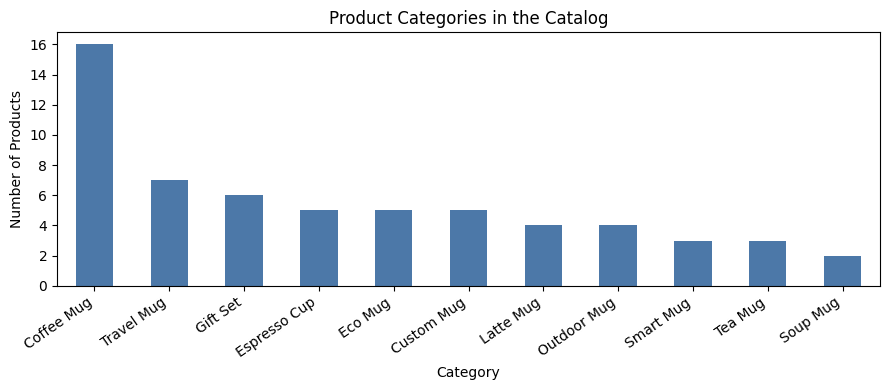

In [5]:
ax = category_summary.plot(kind="bar", x="Category", y="Products", legend=False, figsize=(9, 4), color="#4C78A8")
ax.set_title("Product Categories in the Catalog")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Products")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [6]:
order_status_summary = orders["status"].value_counts().rename_axis("Order status").reset_index(name="Order lines")
order_status_summary

,Order status,Order lines
0,Delivered,344
1,Shipped,142
2,Processing,127
3,Pending,49
4,Cancelled,38


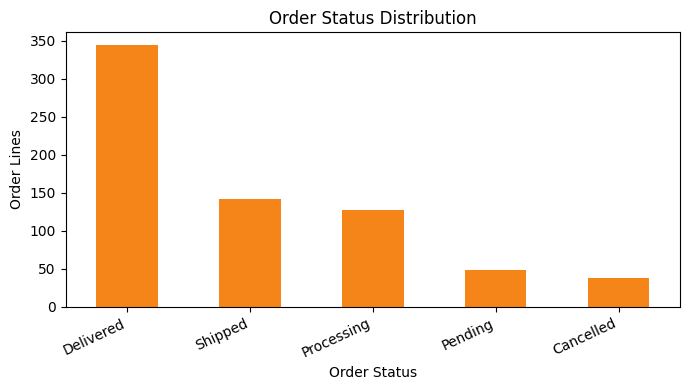

In [7]:
ax = order_status_summary.plot(kind="bar", x="Order status", y="Order lines", legend=False, figsize=(7, 4), color="#F58518")
ax.set_title("Order Status Distribution")
ax.set_xlabel("Order Status")
ax.set_ylabel("Order Lines")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 4. Intent Classification: Rule-based Baseline vs Machine Learning

In [8]:
intent_rows = []
for intent in intents:
    for query in intent.get("queries", []):
        intent_rows.append({"text": query, "tag": intent["tag"]})

intent_df = pd.DataFrame(intent_rows)
intent_df.head()

,text,tag
0,Hi,greeting
1,Hey,greeting
2,How are you,greeting
3,Is anyone there?,greeting
4,Hello,greeting


In [9]:
def stratified_split(df):
    counts = df["tag"].value_counts()
    rare_tags = counts[counts < 2].index
    common = df[~df["tag"].isin(rare_tags)].copy()
    rare = df[df["tag"].isin(rare_tags)].copy()

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=108)
    train_idx, test_idx = next(splitter.split(common["text"], common["tag"]))
    train_df = pd.concat([common.iloc[train_idx], rare], ignore_index=True)
    test_df = common.iloc[test_idx].reset_index(drop=True)
    return train_df, test_df


train_df, test_df = stratified_split(intent_df)

len(train_df), len(test_df), train_df["tag"].nunique(), test_df["tag"].nunique()

(249, 83, 38, 38)

In [10]:
def rule_based_predict(text, train_data):
    text_tokens = set(str(text).lower().split())
    best_tag = None
    best_score = -1
    for tag, group in train_data.groupby("tag"):
        tag_text = " ".join(group["text"].str.lower())
        tag_tokens = set(tag_text.split())
        score = len(text_tokens & tag_tokens)
        if score > best_score:
            best_score = score
            best_tag = tag
    return best_tag


rule_predictions = [rule_based_predict(text, train_df) for text in test_df["text"]]

ml_model = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2))),
    ("classifier", LinearSVC(random_state=108)),
])
ml_model.fit(train_df["text"], train_df["tag"])
ml_predictions = ml_model.predict(test_df["text"])

def metric_row(name, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1-score": round(f1, 3),
    }

intent_model_comparison = pd.DataFrame([
    metric_row("Rule-based baseline", test_df["tag"], rule_predictions),
    metric_row("TF-IDF + Linear SVM", test_df["tag"], ml_predictions),
])

intent_model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Rule-based baseline,0.458,0.366,0.458,0.390
1,TF-IDF + Linear SVM,0.663,0.578,0.663,0.602


In [11]:
print(classification_report(test_df["tag"], ml_predictions, zero_division=0))

                                  precision    recall  f1-score   support

                 account_profile       0.50      0.33      0.40         3
                     admin_login       1.00      1.00      1.00         1
                     bulk_orders       1.00      1.00      1.00         2
                    cancel_order       1.00      1.00      1.00         3
               care_instructions       0.00      0.00      0.00         1
                    create_order       0.75      1.00      0.86         3
                customer_service       1.00      1.00      1.00         1
                        delivery       0.75      0.75      0.75         4
                           funny       0.00      0.00      0.00         1
                           gifts       0.80      1.00      0.89         4
                         goodbye       0.00      0.00      0.00         1
                        greeting       0.00      0.00      0.00         2
                           items     

In [12]:
labels = sorted(test_df["tag"].unique())
cm = confusion_matrix(test_df["tag"], ml_predictions, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df

,account_profile,admin_login,bulk_orders,cancel_order,care_instructions,create_order,customer_service,delivery,funny,gifts,...,returns_refunds,shippable_cities,shipping_costs_time,sizes,technical_support,thanks,update_address,update_order_status,user_preferences_personalization,warranty_repairs
account_profile,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
admin_login,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
bulk_orders,0,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cancel_order,0,0,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
care_instructions,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
create_order,0,0,0,0,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
customer_service,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
delivery,0,0,0,0,0,0,0,3,0,0,...,0,0,1,0,0,0,0,0,0,0
funny,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
gifts,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


## 5. Product Category Prediction: Naive Bayes vs SVM vs Random Forest

In [13]:
products["category_text"] = (
    products["name"].fillna("") + " " +
    products["color"].fillna("") + " " +
    products["size"].fillna("") + " " +
    products["material"].fillna("") + " " +
    products["description"].fillna("")
)

product_train, product_test = train_test_split(
    products,
    test_size=0.30,
    random_state=108,
    stratify=products["category"],
)

category_models = {
    "Naive Bayes": Pipeline([
        ("vectorizer", CountVectorizer()),
        ("classifier", MultinomialNB()),
    ]),
    "Linear SVM": Pipeline([
        ("vectorizer", TfidfVectorizer(ngram_range=(1, 2))),
        ("classifier", LinearSVC(random_state=108)),
    ]),
    "Random Forest": Pipeline([
        ("vectorizer", TfidfVectorizer()),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=108)),
    ]),
}

category_results = []
category_predictions = {}
for name, model in category_models.items():
    model.fit(product_train["category_text"], product_train["category"])
    predictions = model.predict(product_test["category_text"])
    category_predictions[name] = predictions
    category_results.append(metric_row(name, product_test["category"], predictions))

category_model_comparison = pd.DataFrame(category_results)
category_model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.556,0.404,0.556,0.433
1,Linear SVM,0.667,0.599,0.667,0.587
2,Random Forest,0.444,0.319,0.444,0.337


In [14]:
best_category_model = category_model_comparison.sort_values("F1-score", ascending=False).iloc[0]["Model"]
print("Best category model:", best_category_model)
print(classification_report(product_test["category"], category_predictions[best_category_model], zero_division=0))

Best category model: Linear SVM
              precision    recall  f1-score   support

  Coffee Mug       0.56      1.00      0.71         5
  Custom Mug       0.00      0.00      0.00         1
     Eco Mug       1.00      0.50      0.67         2
Espresso Cup       1.00      1.00      1.00         1
    Gift Set       1.00      0.50      0.67         2
   Latte Mug       0.00      0.00      0.00         1
 Outdoor Mug       0.00      0.00      0.00         1
   Smart Mug       1.00      1.00      1.00         1
    Soup Mug       0.00      0.00      0.00         1
     Tea Mug       1.00      1.00      1.00         1
  Travel Mug       0.50      1.00      0.67         2

    accuracy                           0.67        18
   macro avg       0.55      0.55      0.52        18
weighted avg       0.60      0.67      0.59        18



## 6. Product Popularity Results

In [15]:
popular_products = (
    orders[orders["status"].str.lower() != "cancelled"]
    .groupby(["product_id", "product_name"], as_index=False)
    .agg(
        orders=("order_number", "nunique"),
        units_sold=("quantity", "sum"),
        revenue=("total_price", "sum"),
    )
    .sort_values(["units_sold", "revenue"], ascending=False)
)

popular_products.head(10)

,product_id,product_name,orders,units_sold,revenue
2,P003,Classic Blue Mug,76,136,1766.64
1,P002,Classic White Mug,83,129,1546.71
0,P001,Classic Red Mug,75,125,1623.75
9,P011,Thermal Steel Mug,42,80,1599.20
3,P004,Large Travel Mug,48,76,1443.24
28,P031,Floral Gift Mug,35,67,1339.33
4,P005,Gift Mug Set,38,65,2274.35
6,P007,Pastel Pink Mug,10,23,310.27
41,P045,Student Budget Mug,13,23,183.77
34,P038,Marble Ceramic Mug,13,22,395.78


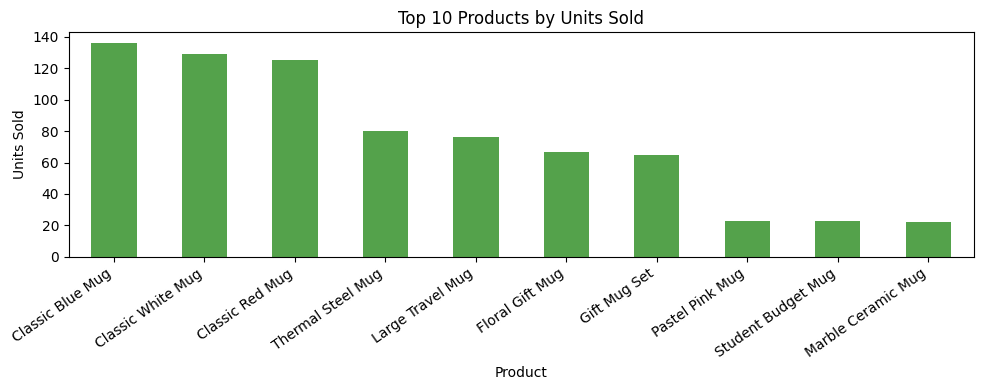

In [16]:
ax = popular_products.head(10).plot(
    kind="bar",
    x="product_name",
    y="units_sold",
    legend=False,
    figsize=(10, 4),
    color="#54A24B",
)
ax.set_title("Top 10 Products by Units Sold")
ax.set_xlabel("Product")
ax.set_ylabel("Units Sold")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 7. Recommendation Evaluation

In [17]:
product_lookup = products.set_index("product_id").to_dict("index")

def product_tokens(product_id):
    product = product_lookup[product_id]
    text = " ".join(str(product.get(field, "")) for field in ["name", "category", "color", "size", "material", "description"])
    return set(text.lower().split())

def content_based_recommend(seed_product_id, k=5):
    seed = product_lookup[seed_product_id]
    seed_tokens = product_tokens(seed_product_id)
    scores = []
    for product_id, product in product_lookup.items():
        if product_id == seed_product_id:
            continue
        tokens = product_tokens(product_id)
        overlap = len(seed_tokens & tokens) / max(len(seed_tokens | tokens), 1)
        score = overlap
        if product["category"] == seed["category"]:
            score += 1.5
        if product["material"] == seed["material"]:
            score += 0.75
        if product["color"] == seed["color"]:
            score += 0.35
        scores.append((product_id, score))
    return [product_id for product_id, score in sorted(scores, key=lambda item: item[1], reverse=True)[:k]]

def interaction_based_recommend(user_id, k=5):
    user_events = interactions[interactions["user_id"] == user_id]
    seen = set(user_events["product_id"])
    preferred_categories = (
        user_events.merge(products[["product_id", "category"]], on="product_id", how="left")
        ["category"]
        .value_counts()
    )
    if preferred_categories.empty:
        return popular_products["product_id"].head(k).tolist()
    scores = []
    for _, product in products.iterrows():
        if product["product_id"] in seen:
            continue
        score = preferred_categories.get(product["category"], 0)
        score += product["stock"] / 100
        scores.append((product["product_id"], score))
    return [product_id for product_id, score in sorted(scores, key=lambda item: item[1], reverse=True)[:k]]

def precision_at_k(recommended, relevant, k):
    top_k = recommended[:k]
    return sum(item in relevant for item in top_k) / max(len(top_k), 1)

def recall_at_k(recommended, relevant, k):
    top_k = recommended[:k]
    return sum(item in relevant for item in top_k) / max(len(relevant), 1)

def reciprocal_rank(recommended, relevant):
    for rank, item in enumerate(recommended, start=1):
        if item in relevant:
            return 1 / rank
    return 0

recommendation_cases = []
for user_id, group in interactions[interactions["action"].isin(["purchase", "review"])].groupby("user_id"):
    relevant = set(group[group["rating"].fillna(0) >= 4]["product_id"])
    if len(relevant) < 2:
        continue
    seed = sorted(relevant)[0]
    recommendation_cases.append({"user_id": user_id, "seed": seed, "relevant": relevant - {seed}})

recommendation_cases = recommendation_cases[:25]
len(recommendation_cases)

25

In [18]:
recommendation_results = []
for case in recommendation_cases:
    content_recs = content_based_recommend(case["seed"], k=5)
    interaction_recs = interaction_based_recommend(case["user_id"], k=5)
    for method, recs in [
        ("Content-based", content_recs),
        ("Interaction-based personalized", interaction_recs),
    ]:
        recommendation_results.append({
            "Method": method,
            "Precision@5": precision_at_k(recs, case["relevant"], 5),
            "Recall@5": recall_at_k(recs, case["relevant"], 5),
            "MRR": reciprocal_rank(recs, case["relevant"]),
        })

recommendation_metrics = (
    pd.DataFrame(recommendation_results)
    .groupby("Method", as_index=False)
    .mean()
    .round(3)
)

recommendation_metrics

,Method,Precision@5,Recall@5,MRR
0,Content-based,0.016,0.021,0.06
1,Interaction-based personalized,0.000,0.000,0.00


In [19]:
recommendation_example = pd.DataFrame([
    {
        "User": case["user_id"],
        "Seed product": case["seed"],
        "Relevant products": ", ".join(sorted(case["relevant"])),
        "Content-based recommendations": ", ".join(content_based_recommend(case["seed"], 5)),
        "Personalized recommendations": ", ".join(interaction_based_recommend(case["user_id"], 5)),
    }
    for case in recommendation_cases[:5]
])

recommendation_example

,User,Seed product,Relevant products,Content-based recommendations,Personalized recommendations
0,U003,P031,P035,"P032, P046, P047, P005, P015","P022, P005, P046, P015, P054"
1,U007,P036,"P044, P047, P052","P013, P040, P035, P014, P058","P002, P008, P003, P001, P016"
2,U008,P004,"P020, P025, P027","P012, P019, P043, P044, P060","P045, P002, P008, P001, P016"
3,U009,P002,"P008, P022, P042, P049, P051","P038, P016, P001, P003, P006","P045, P003, P001, P016, P006"
4,U011,P022,"P042, P058","P023, P054, P024, P055, P002","P045, P002, P008, P003, P016"


## 8. Market Basket Analysis with Support, Confidence, and Lift

In [20]:
baskets = (
    orders[orders["status"].str.lower() != "cancelled"]
    .groupby("customer_email")["product_id"]
    .apply(lambda values: sorted(set(values)))
)

baskets = baskets[baskets.apply(len) >= 2]
basket_count = len(baskets)

item_counts = Counter()
pair_counts = Counter()
for basket in baskets:
    for item in basket:
        item_counts[item] += 1
    for pair in combinations(basket, 2):
        pair_counts[pair] += 1

rules = []
for (left, right), count in pair_counts.items():
    support = count / basket_count
    confidence = count / item_counts[left]
    right_support = item_counts[right] / basket_count
    lift = confidence / max(right_support, 0.000001)
    if count >= 3:
        rules.append({
            "Rule": f"{left} -> {right}",
            "Support count": count,
            "Support": support,
            "Confidence": confidence,
            "Lift": lift,
        })
        reverse_confidence = count / item_counts[right]
        left_support = item_counts[left] / basket_count
        rules.append({
            "Rule": f"{right} -> {left}",
            "Support count": count,
            "Support": support,
            "Confidence": reverse_confidence,
            "Lift": reverse_confidence / max(left_support, 0.000001),
        })

association_rules = pd.DataFrame(rules).sort_values(["Lift", "Confidence", "Support"], ascending=False)
association_rules.head(15).round(3)

,Rule,Support count,Support,Confidence,Lift
340,P024 -> P055,3,0.038,0.750,12.000
341,P055 -> P024,3,0.038,0.600,12.000
287,P021 -> P016,3,0.038,0.750,6.000
286,P016 -> P021,3,0.038,0.300,6.000
271,P035 -> P025,3,0.038,0.750,5.455
270,P025 -> P035,3,0.038,0.273,5.455
255,P040 -> P017,3,0.038,0.600,4.364
254,P017 -> P040,3,0.038,0.273,4.364
285,P045 -> P015,3,0.038,0.231,3.692
284,P015 -> P045,3,0.038,0.600,3.692


## 9. User Survey Evaluation

In [21]:
rating_columns = [
    "chatbot_accuracy",
    "rating_recommendations",
    "rating_speed",
    "rating_overall",
]

survey_summary = (
    survey[rating_columns]
    .mean()
    .round(2)
    .rename_axis("Metric")
    .reset_index(name="Average rating out of 5")
)

survey_summary

,Metric,Average rating out of 5
0,chatbot_accuracy,4.30
1,rating_recommendations,4.13
2,rating_speed,4.53
3,rating_overall,4.70


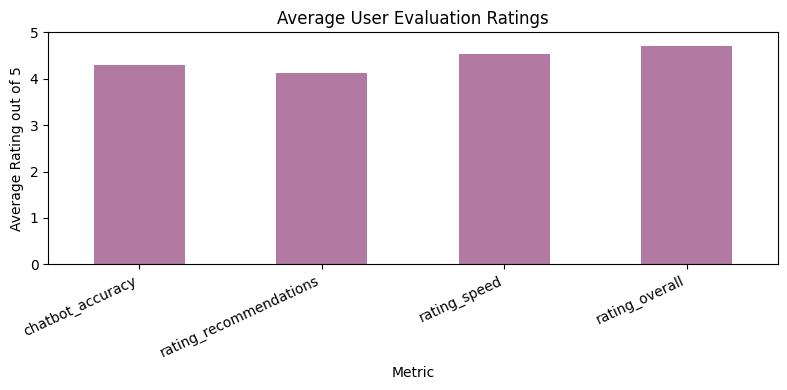

In [22]:
ax = survey_summary.plot(
    kind="bar",
    x="Metric",
    y="Average rating out of 5",
    legend=False,
    figsize=(8, 4),
    color="#B279A2",
)
ax.set_title("Average User Evaluation Ratings")
ax.set_xlabel("Metric")
ax.set_ylabel("Average Rating out of 5")
ax.set_ylim(0, 5)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 10. Report-ready Test Case Table

In [23]:
test_cases = pd.DataFrame([
    {
        "User query": "What products do you sell?",
        "Expected intent": "items",
        "Expected behaviour": "Shows product catalog information",
    },
    {
        "User query": "Track my order",
        "Expected intent": "order_status",
        "Expected behaviour": "Asks for/checks order details",
    },
    {
        "User query": "Recommend something like P004",
        "Expected intent": "recommendations",
        "Expected behaviour": "Shows similar travel mug recommendations",
    },
    {
        "User query": "Show best selling mugs",
        "Expected intent": "product_popularity_analysis",
        "Expected behaviour": "Shows product popularity from order history",
    },
    {
        "User query": "Run market basket analysis",
        "Expected intent": "market_basket_analysis",
        "Expected behaviour": "Shows frequently bought together products",
    },
    {
        "User query": "Predict category for insulated travel mug",
        "Expected intent": "product_category_prediction",
        "Expected behaviour": "Predicts the product category using text features",
    },
])

test_cases

,User query,Expected intent,Expected behaviour
0,What products do you sell?,items,Shows product catalog information
1,Track my order,order_status,Asks for/checks order details
2,Recommend something like P004,recommendations,Shows similar travel mug recommendations
3,Show best selling mugs,product_popularity_analysis,Shows product popularity from order history
4,Run market basket analysis,market_basket_analysis,Shows frequently bought together products
5,Predict category for insulated travel mug,product_category_prediction,Predicts the product category using text features
